# Цель проекта

### Выявить преимущество Нейронных сетей перед моделями
### Подобрать дата сет
### Подести итоги 

# Подключение библиотек

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

In [2]:

from tensorflow import keras

## Загружаем дата сет

In [3]:
df = pd.read_csv("text.csv")
df.head()

,Unnamed: 0,text,label
0,0,i just feel really helpless and heavy hearted,4
1,1,ive enjoyed being able to slouch about relax a...,0
2,2,i gave up my internship with the dmrg and am f...,4
3,3,i dont know i feel so lost,0
4,4,i am a kindergarten teacher and i am thoroughl...,4


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 416809 entries, 0 to 416808
Data columns (total 3 columns):
 #   Column      Non-Null Count   Dtype
---  ------      --------------   -----
 0   Unnamed: 0  416809 non-null  int64
 1   text        416809 non-null  str  
 2   label       416809 non-null  int64
dtypes: int64(2), str(1)
memory usage: 9.5 MB


### Набор данных содержит 416 808 строк и 3-х столбцов без пропущенных значений.
#### Unnamed - Уникальный номер строки
#### text - Текст в котором показаны эмоции
#### label - код показывающий эмоции текста 
* (0 - Печаль)
* (1 - Радостный)
* (2 - Любовный)
* (3 - Гневный)
* (4 - Страх)
* (5 - Удивление)

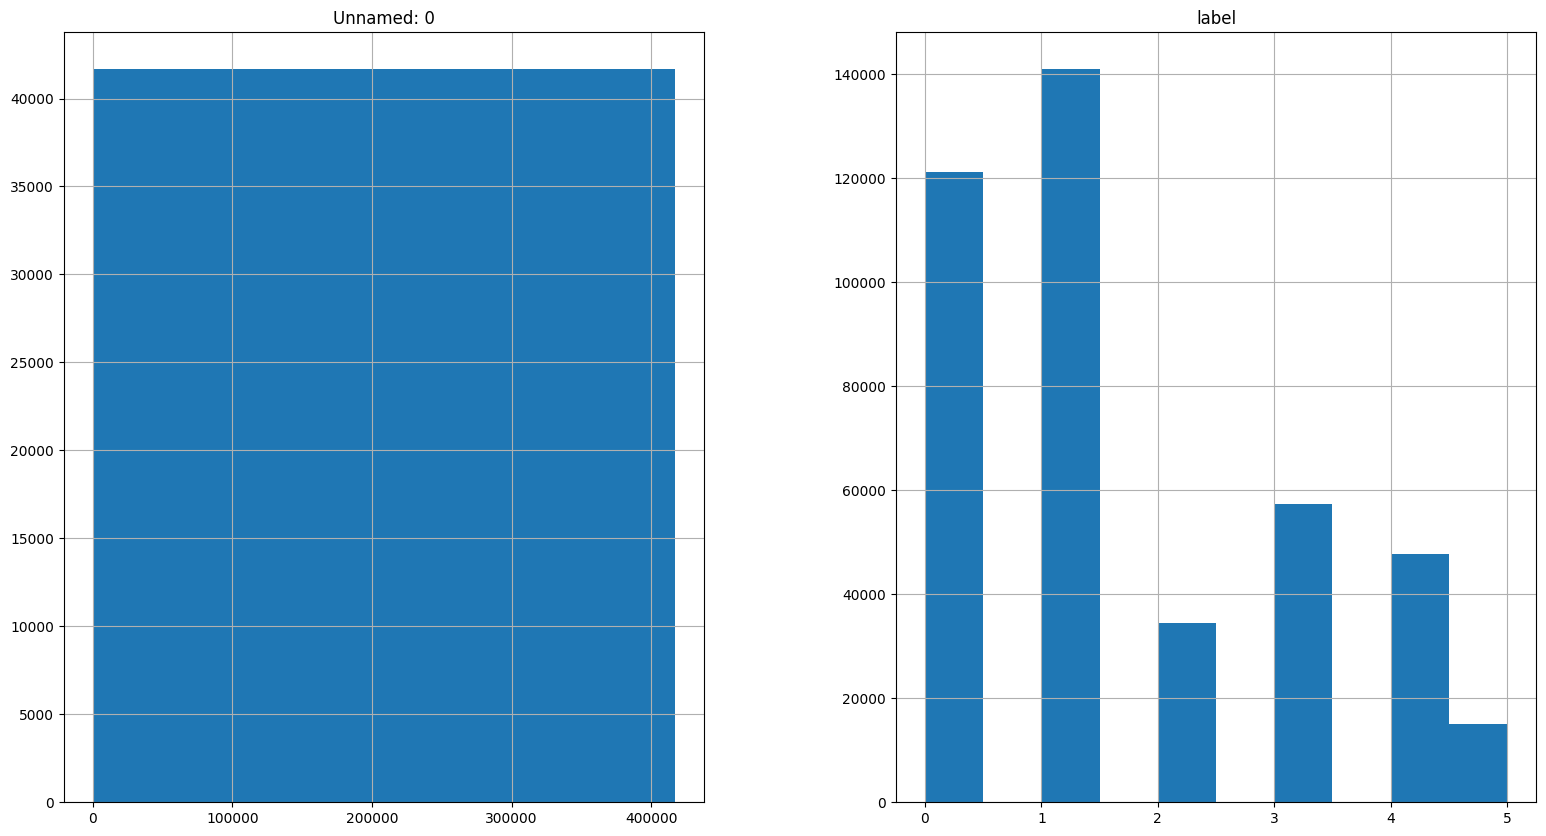

In [5]:
df.hist(figsize=(19,10));

#### Наблюдая график, можно заметить, что радостных и печальных сообщений больше всего

#### Этат блок требовался для сокращения дата сета, что бы меньше нагружать систему, и после того, как система заработает корректно вернуть полноценный дата сет

In [6]:
# np.random.seed(42)

# # Сокращаем до 100,000 записей случайным образом
# df_sampled = df.sample(n=100000, random_state=42)

# print(f"Было записей: {len(df)}")
# print(f"Стало записей: {len(df_sampled)}")
# print(f"Сокращение наФ {len(df) - len(df_sampled)} записей")
# print(f"Процент от оригинала: {len(df_sampled)/len(df)*100:.2f}%")

# # Перезаписываем df (или создаем новый)
# df = df_sampled.copy()

In [7]:
df

,Unnamed: 0,text,label
0,0,i just feel really helpless and heavy hearted,4
1,1,ive enjoyed being able to slouch about relax a...,0
2,2,i gave up my internship with the dmrg and am f...,4
3,3,i dont know i feel so lost,0
4,4,i am a kindergarten teacher and i am thoroughl...,4
...,...,...,...
416804,416804,i feel like telling these horny devils to find...,2
416805,416805,i began to realize that when i was feeling agi...,3
416806,416806,i feel very curious be why previous early dawn...,5
416807,416807,i feel that becuase of the tyranical nature of...,3


========================================

In [ ]:
import pandas as pd
from deep_translator import GoogleTranslator
from concurrent.futures import ThreadPoolExecutor
from tqdm import tqdm # Библиотека для полоски прогресса

# 1. Твоя функция (лучше создавать объект транслятора один раз)
translator = GoogleTranslator(source='en', target='ru')

def translate_row(text):
    if not text or not isinstance(text, str):
        return ""
    try:
        return translator.translate(text)
    except Exception as e:
        return f"Error: {e}"

# 2. Выполнение в потоках
def parallel_translate(series, workers=10):
    with ThreadPoolExecutor(max_workers=workers) as executor:
        # map выполняет функцию для каждого элемента в потоках
        results = list(tqdm(executor.map(translate_row, series), total=len(series)))
    return results

# Запуск
df['text_russian'] = parallel_translate(df['text'], workers=50)

In [ ]:
df

### Примеры текста с переводом

In [12]:
from deep_translator import GoogleTranslator
import time

# Инициализируем переводчик
translator = GoogleTranslator(source='auto', target='russian')

print("="*70)
print("📊 ПРИМЕРЫ ТЕКСТОВ ПО LABEL (0-5) С ПЕРЕВОДОМ")
print("="*70)

for label_value in range(6):
    label_records = df[df['label'] == label_value]
    
    if len(label_records) > 0:
        record = label_records.iloc[0]
        original = record['text']
        
        print(f"\n🎯 LABEL {label_value} (всего: {len(label_records)})")
        print("-"*50)
        print(f"📝 Оригинал: {original[:150]}{'...' if len(str(original)) > 150 else ''}")
        
        try:
            translated = translator.translate(str(original)[:5000])
            print(f"🇷🇺 Перевод:  {translated[:150]}{'...' if len(translated) > 150 else ''}")
        except Exception as e:
            print(f"❌ Ошибка: {e}")
        
        time.sleep(0.5)
    else:
        print(f"\n❌ LABEL {label_value}: записей нет")

print("\n" + "="*70)

📊 ПРИМЕРЫ ТЕКСТОВ ПО LABEL (0-5) С ПЕРЕВОДОМ
ERROR! Session/line number was not unique in database. History logging moved to new session 479

🎯 LABEL 0 (всего: 121187)
--------------------------------------------------
📝 Оригинал: ive enjoyed being able to slouch about relax and unwind and frankly needed it after those last few weeks around the end of uni and the expo i have lat...
🇷🇺 Перевод:  Мне нравилось иметь возможность расслабиться и отдохнуть, и, честно говоря, мне это было нужно после последних нескольких недель после окончания униве...

🎯 LABEL 1 (всего: 141067)
--------------------------------------------------
📝 Оригинал: i fear that they won t ever feel that delicious excitement of christmas eve at least not in the same way i remember doing it
🇷🇺 Перевод:  я боюсь, что они никогда не почувствуют то восхитительное волнение кануна Рождества, по крайней мере, не так, как я это помню

🎯 LABEL 2 (всего: 34554)
--------------------------------------------------
📝 Оригинал: i wou

# Построим матрицу, для наших признаков

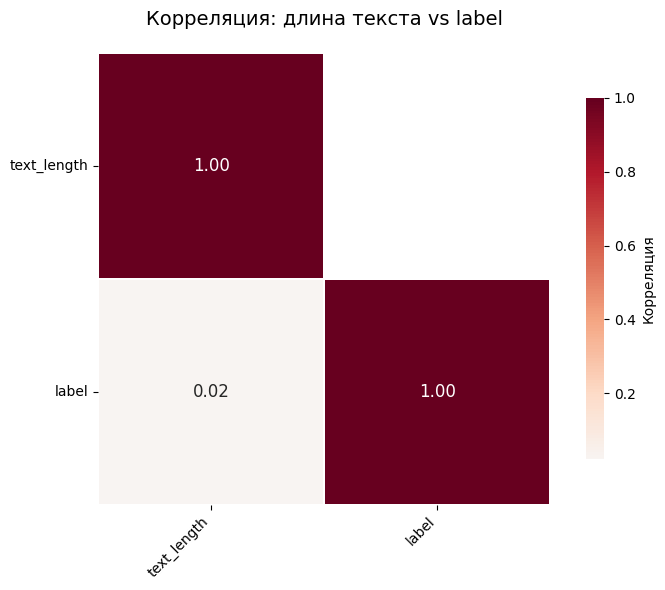


📊 Значения корреляции:
             text_length     label
text_length     1.000000  0.020976
label           0.020976  1.000000


In [13]:
def plot_2feature_heatmap(corr_matrix, title='Корреляционная матрица'):
    plt.figure(figsize=(8, 6))
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
    
    # Тепловая карта
    sns.heatmap(corr_matrix, 
                annot=True,         
                linewidths=0.2,       
                fmt='.2f',            
                cmap='RdBu_r',          
                center=0,             
                square=True,          
                mask=mask,         
                cbar_kws={'shrink': 0.8, 'label': 'Корреляция'},
                annot_kws={'size': 12})
    
    plt.title(title, fontsize=14, pad=20)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()
    
    print("\n📊 Значения корреляции:")
    print(corr_matrix)

feature1 = df['text_length'] = df['text'].str.len()
feature2 = df['label']

corr_2features = pd.DataFrame({
    'text_length': feature1,
    'label': feature2
}).corr()

plot_2feature_heatmap(corr_2features, 'Корреляция: длина текста vs label')

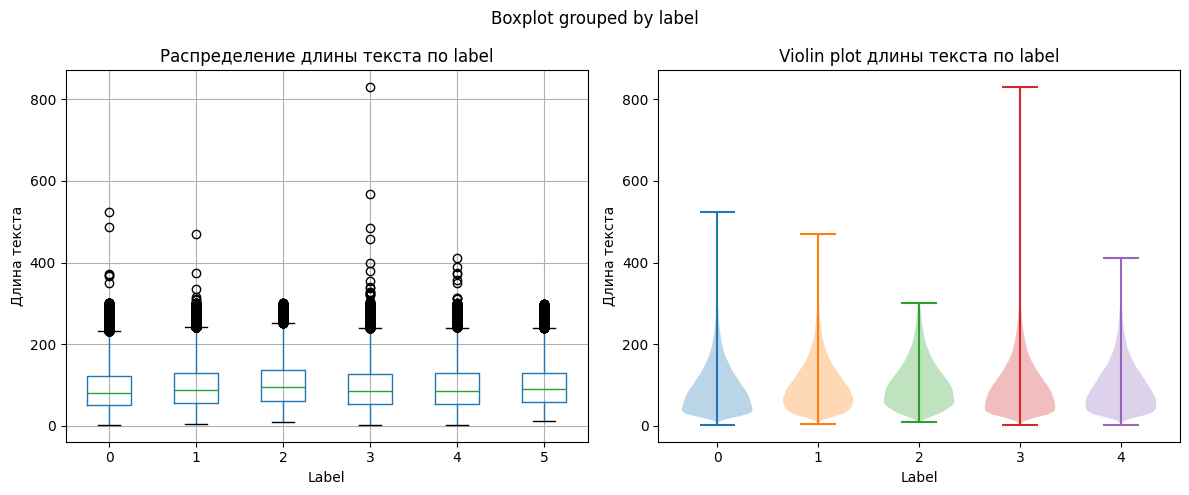

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

df.boxplot(column='text_length', by='label', ax=axes[0])
axes[0].set_title('Распределение длины текста по label')
axes[0].set_xlabel('Label')
axes[0].set_ylabel('Длина текста')

for label in range(5):
    data = df[df['label'] == label]['text_length']
    axes[1].violinplot(data, positions=[label], widths=0.7)
axes[1].set_title('Violin plot длины текста по label')
axes[1].set_xlabel('Label')
axes[1].set_ylabel('Длина текста')
axes[1].set_xticks(range(5))

plt.tight_layout()
plt.show()

### Скошенное распределение

# Обучение модели классификации

In [15]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [16]:
pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [17]:
from sklearn.feature_extraction.text import TfidfVectorizer
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import warnings

In [18]:
df

,Unnamed: 0,text,label,text_length
0,0,i just feel really helpless and heavy hearted,4,45
1,1,ive enjoyed being able to slouch about relax a...,0,234
2,2,i gave up my internship with the dmrg and am f...,4,63
3,3,i dont know i feel so lost,0,26
4,4,i am a kindergarten teacher and i am thoroughl...,4,222
...,...,...,...,...
416804,416804,i feel like telling these horny devils to find...,2,132
416805,416805,i began to realize that when i was feeling agi...,3,111
416806,416806,i feel very curious be why previous early dawn...,5,90
416807,416807,i feel that becuase of the tyranical nature of...,3,222


In [19]:
vectorizer = TfidfVectorizer(max_features=1000, stop_words='english')
X = vectorizer.fit_transform(df['text'])
y = df['label'].values

In [20]:
X

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 2392319 stored elements and shape (416809, 1000)>

In [21]:
y

array([4, 0, 4, ..., 5, 3, 5])

In [22]:
print(f"📊 Размер матрицы признаков: {X.shape}")
print(f"🎯 Распределение label:")
label_counts = df['label'].value_counts().sort_index()
for label in range(6):
    print(f"   Label {label}: {label_counts.get(label, 0)} записей")

📊 Размер матрицы признаков: (416809, 1000)
🎯 Распределение label:
   Label 0: 121187 записей
   Label 1: 141067 записей
   Label 2: 34554 записей
   Label 3: 57317 записей
   Label 4: 47712 записей
   Label 5: 14972 записей


In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

In [24]:
model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    objective='multi:softprob',  # для мультикласса
    num_class=5,  # 5 классов эмоций
    use_label_encoder=False,
    eval_metric='mlogloss',
    random_state=42
)

model.fit(X_train, y_train)

# Предсказания
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)

In [25]:
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.94      0.88      0.91     24238
           1       0.85      0.89      0.87     28214
           2       0.73      0.88      0.80      6911
           3       0.89      0.82      0.86     11463
           4       0.89      0.76      0.82      9542
           5       0.69      0.92      0.79      2994

    accuracy                           0.86     83362
   macro avg       0.83      0.86      0.84     83362
weighted avg       0.87      0.86      0.87     83362



#### Можем наблюдать, что модель  XGBoost, справилась хорошо
- Среднее Арифметическое число по f1-score = 84.16% (0.84)
- XGBoost - Используется для решения задач классификации

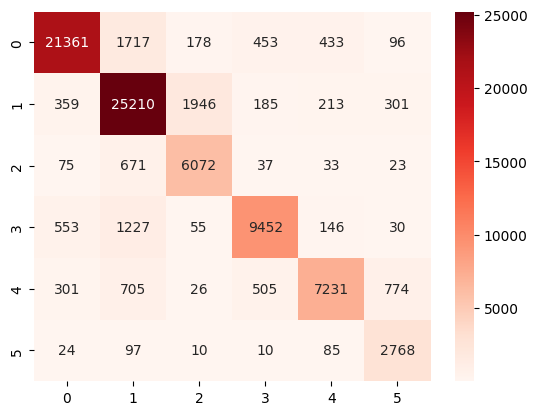

In [26]:
conf_matrix = confusion_matrix(y_test, y_pred)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Reds')
plt.show()

# Обучение нейронной модели

In [27]:
X_train

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 1915003 stored elements and shape (333447, 1000)>

In [28]:
np.min(y_train)

np.int64(0)

In [29]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.layers import InputLayer, Dense
from sklearn.preprocessing import StandardScaler

# scaler = StandardScaler()
# X_train_scaled = scaler.fit_transform(X_train)
# X_test_scaled = scaler.transform(X_test)

model = tf.keras.Sequential([
    InputLayer(shape=(1000,)),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(6, activation='softmax')
])

# class_weight = {0: 1.0, 1: 9.0}

model.compile(optimizer='adam', 
              # loss='binary_crossentropy', 
              loss=tf.keras.losses.sparse_categorical_crossentropy, 
              metrics=['accuracy'])

In [30]:
# tf.keras.losses.categorical_crossentropy

In [31]:
print(model.summary())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │        64,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │           198 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 66,342 (259.15 KB)

 Trainable params: 66,342 (259.15 KB)

 Non-trainable params: 0 (0.00 B)

None


In [32]:
# history = model.fit(X_train, y_train, 
#                     epochs=50, 
#                     # batch_size=64, 
#                     validation_split=0.1,)
#                     # class_weight=class_weight,)
model.fit(X_train, y_train, 
                    epochs=20)
                    # batch_size=64, 
                    # class_weight=class_weight,)

Epoch 1/20
10421/10421 ━━━━━━━━━━━━━━━━━━━━ 60s 6ms/step - accuracy: 0.8574 - loss: 0.3505
Epoch 2/20
10421/10421 ━━━━━━━━━━━━━━━━━━━━ 74s 7ms/step - accuracy: 0.8736 - loss: 0.2887
Epoch 3/20
10421/10421 ━━━━━━━━━━━━━━━━━━━━ 94s 8ms/step - accuracy: 0.8759 - loss: 0.2784
Epoch 4/20
10421/10421 ━━━━━━━━━━━━━━━━━━━━ 97s 4ms/step - accuracy: 0.8792 - loss: 0.2704
Epoch 5/20
10421/10421 ━━━━━━━━━━━━━━━━━━━━ 80s 8ms/step - accuracy: 0.8817 - loss: 0.2629
Epoch 6/20
10421/10421 ━━━━━━━━━━━━━━━━━━━━ 86s 8ms/step - accuracy: 0.8851 - loss: 0.2555
Epoch 7/20
10421/10421 ━━━━━━━━━━━━━━━━━━━━ 137s 8ms/step - accuracy: 0.8875 - loss: 0.2487
Epoch 8/20
10421/10421 ━━━━━━━━━━━━━━━━━━━━ 74s 7ms/step - accuracy: 0.8897 - loss: 0.2425
Epoch 9/20
10421/10421 ━━━━━━━━━━━━━━━━━━━━ 82s 7ms/step - accuracy: 0.8917 - loss: 0.2366
Epoch 10/20
10421/10421 ━━━━━━━━━━━━━━━━━━━━ 49s 4ms/step - accuracy: 0.8943 - loss: 0.2308
Epoch 11/20
10421/10421 ━━━━━━━━━━━━━━━━━━━━ 50s 5ms/step - accuracy: 0.8958 - loss: 0.2

In [33]:
predictions = model.predict(X_test)

2606/2606 ━━━━━━━━━━━━━━━━━━━━ 23s 9ms/step


In [34]:
predictions

array([[1.6444272e-03, 4.5260534e-01, 5.4567432e-01, 5.0634342e-05,
        2.5187908e-05, 1.3473964e-09],
       [1.2528853e-05, 2.1483190e-04, 9.9972278e-01, 2.1037064e-05,
        2.7432581e-05, 1.4323111e-06],
       [2.2116168e-05, 6.5771637e-05, 3.2631974e-07, 2.7941473e-04,
        9.9963224e-01, 2.2728672e-10],
       ...,
       [9.9944621e-01, 1.3927878e-04, 4.2130409e-06, 4.0920795e-04,
        1.1155571e-06, 5.6619119e-12],
       [2.3958185e-01, 8.9641289e-06, 7.9308442e-11, 4.1477000e-09,
        7.6040918e-01, 4.8263001e-11],
       [7.3221731e-06, 9.9809891e-01, 3.8894315e-05, 1.8511916e-03,
        3.7190825e-06, 2.4614227e-28]], dtype=float32)

In [35]:
y_pred = np.argmax(predictions, axis=1)

In [36]:
y_pred

array([2, 2, 4, ..., 0, 4, 1])

In [37]:
print(classification_report(y_test, y_pred,
                           labels=[0, 1, 2, 3, 4, 5],  # все 5 классов
                           target_names=['Гнев', 'Любовь', 'Радость', 'Печаль', 'Страх', 'Удивление']))

              precision    recall  f1-score   support

        Гнев       0.90      0.90      0.90     24238
      Любовь       0.88      0.89      0.89     28214
     Радость       0.77      0.74      0.75      6911
      Печаль       0.82      0.86      0.84     11463
       Страх       0.84      0.77      0.80      9542
   Удивление       0.71      0.74      0.72      2994

    accuracy                           0.86     83362
   macro avg       0.82      0.82      0.82     83362
weighted avg       0.86      0.86      0.86     83362



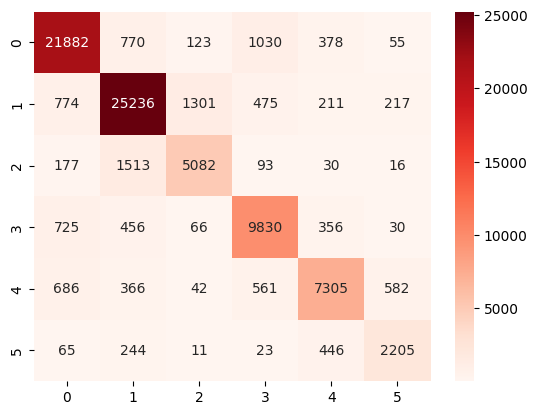

In [38]:
conf_matrix = confusion_matrix(y_test, y_pred)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Reds')
plt.show()

# RandomForestClassifier

In [42]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

In [43]:
def train_random_forest_model(df, text_column='text', label_column='label', max_features=1000, test_size=0.2, random_state=42):
    print("🔄 Векторизация текстов...")
    vectorizer = TfidfVectorizer(max_features=max_features, stop_words='english')
    X = vectorizer.fit_transform(df[text_column])
    y = df[label_column].values
    

    print(f"📊 Размер матрицы признаков: {X.shape}")
    print(f"🎯 Распределение label:")
    label_counts = df[label_column].value_counts().sort_index()
    for label in sorted(df[label_column].unique()):
        print(f"   Label {label}: {label_counts.get(label, 0)} записей")
    
    # Разделение на train/test
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, stratify=y, random_state=random_state
    )
    
    # Модель RandomForest
    print("🌲 Обучение модели RandomForest...")
    model = RandomForestClassifier(
        n_estimators=300,        
        max_depth=15,            
        min_samples_split=5,     
        min_samples_leaf=2,      
        max_features='sqrt',      
        bootstrap=True,           
        oob_score=True,          
        n_jobs=-1,                
        random_state=random_state,
        class_weight='balanced'  
    )
    
    # Обучение
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
 
    print("\n Отчет по классификации:")
    print(classification_report(y_test, y_pred))
    
    # Важность признаков (опционально)
    feature_importance = pd.DataFrame({
        'feature': vectorizer.get_feature_names_out()[:10],  # Топ-10 признаков
        'importance': model.feature_importances_[:10]
    }).sort_values('importance', ascending=False)

    if hasattr(model, 'oob_score_'):
        print(f"\n📊 Out-of-Bag точность: {model.oob_score_:.4f}")
    
    return model, vectorizer, X_test, y_test, y_pred

model, vectorizer, X_test, y_test, y_pred = train_random_forest_model(df)

🔄 Векторизация текстов...
📊 Размер матрицы признаков: (416809, 1000)
🎯 Распределение label:
   Label 0: 121187 записей
   Label 1: 141067 записей
   Label 2: 34554 записей
   Label 3: 57317 записей
   Label 4: 47712 записей
   Label 5: 14972 записей
🌲 Обучение модели RandomForest...

 Отчет по классификации:
              precision    recall  f1-score   support

           0       0.48      0.93      0.64     24238
           1       0.95      0.18      0.30     28214
           2       0.67      0.88      0.76      6911
           3       0.89      0.78      0.83     11463
           4       0.89      0.69      0.78      9542
           5       0.62      0.99      0.76      2994

    accuracy                           0.63     83362
   macro avg       0.75      0.74      0.68     83362
weighted avg       0.76      0.63      0.58     83362


📊 Out-of-Bag точность: 0.5920


### Матрица ошибок

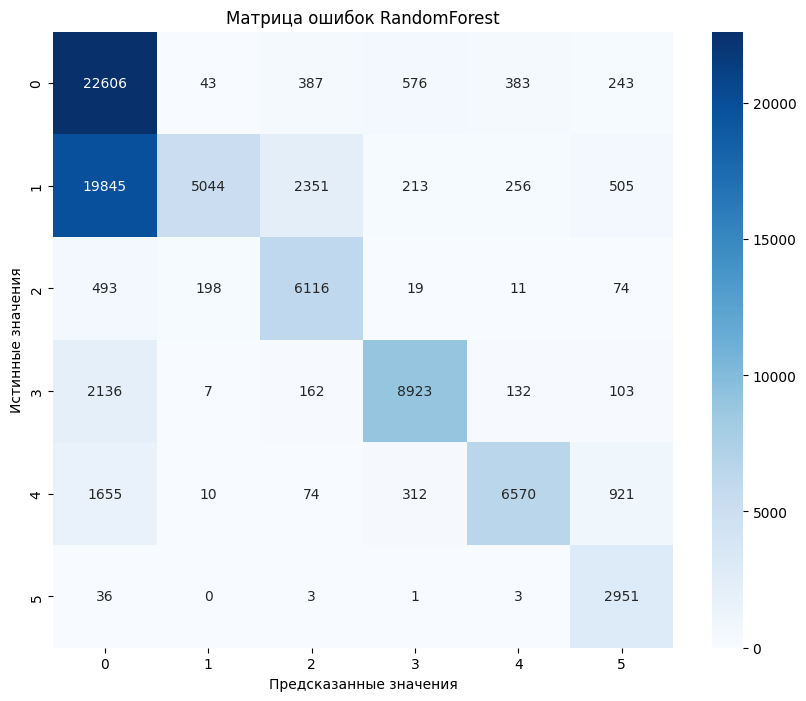

In [44]:
# Дополнительно можно посмотреть матрицу ошибок
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Матрица ошибок RandomForest')
plt.ylabel('Истинные значения')
plt.xlabel('Предсказанные значения')
plt.show()

# Вывод по проделанной работе: 

Модель классификации показала себя очень хорошо, средний показатель верного ответа у модели: 0.84

Модель "Дерево случаныйх решений", показала себя хуже всех, средний показатель верного ответа у модели: 0.67

Модель нейронных ситей так же показала себя хорошо, средний показатель верного ответа: 0.82

Дата сет составил: 416809 rows × 3 columns, в таблице 2 признака
 * 1-й признак это текст, который описавает эмоцию
 * 2-й признак это числовое значение, которое демонстрирует эмоцию текста

Был выбран дата сет, где содержится текст пользователей, и отображает их эмоцию в тексте

* В принципе нейронная модель сильна тем, что она может распознать паттерны или скрытые зависимости в датасете, что сильно помогает в обучении и тем самым улучшая её эффективность. В этом датасете, нейронная модель найти таких паттернов не смогла.

* Модель лучше использовать в случаях, когда нужно отнести объект к одному из предопределённых классов на основе его признаков.


* URL in dataset: https://www.kaggle.com/datasets/nelgiriyewithana/emotions
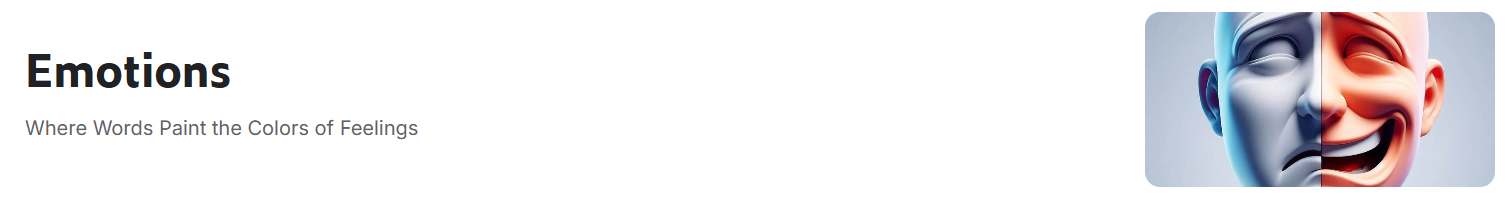